# 02 - EDA y Preparacion para Inversion



In [12]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.fs as fs

sns.set(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [13]:
# Carga directa del parquet (sin búsqueda automática)
PARQUET_PATH = r"C:\Users\alons\Desktop\Práctica 7\sp500_history.parquet"

datos_crudos_df = pq.read_table(PARQUET_PATH).to_pandas()
nombre_origen = PARQUET_PATH
tipo_origen = "ruta fija parquet"

print("Origen detectado:", nombre_origen)
print("Tipo detectado:", tipo_origen)
print("Shape inicial:", datos_crudos_df.shape)
display(datos_crudos_df.head())


Origen detectado: C:\Users\alons\Desktop\Práctica 7\sp500_history.parquet
Tipo detectado: ruta fija parquet
Shape inicial: (7250110, 14)


,date,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
0,1999-11-18,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,27.188307,29.877260,23.901808,25.545057,74862288.0,42.7500
1,1999-11-19,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.657097,25.694445,23.789768,24.349968,18236110.0,40.7500
2,1999-11-22,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,24.686087,26.067909,23.939156,26.067909,7874048.5,43.6250
3,1999-11-23,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.395672,26.067909,24.051195,24.051195,7153099.0,40.2500
4,1999-11-24,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,23.976501,25.059551,23.901808,24.536699,5797720.5,41.0625


## 2) Seleccion de columnas relevantes

El analisis se centra en fecha, identificador de activo, precios y volumen.
Se excluyen columnas no utiles para evaluar riesgo/rentabilidad.


In [14]:
# Copia base y normalizacion de nombres

datos_base_df = datos_crudos_df.copy()
datos_base_df.columns = [str(c).strip().lower() for c in datos_base_df.columns]

# Detectamos columnas estructurales
columnas_fecha_candidatas = ["date", "datetime", "timestamp", "fecha"]
columna_fecha = next((c for c in columnas_fecha_candidatas if c in datos_base_df.columns), None)

columnas_activo_candidatas = ["symbol", "ticker", "asset", "activo"]
columna_activo = next((c for c in columnas_activo_candidatas if c in datos_base_df.columns), None)

# Priorizamos precio ajustado para analisis de retornos
columnas_precio_orden = ["adj_close", "close", "unadjusted_close"]
columna_precio_referencia = next((c for c in columnas_precio_orden if c in datos_base_df.columns), None)

# Detectamos columnas de precio disponibles
columnas_precio_disponibles = [
    c for c in ["open", "high", "low", "close", "adj_close", "unadjusted_close"]
    if c in datos_base_df.columns
]

# Detectamos volumen
columna_volumen = "volume" if "volume" in datos_base_df.columns else None

# Lista de columnas financieras relevantes para auditoria
columnas_relevantes = []
for c in [columna_fecha, columna_activo] + columnas_precio_disponibles + [columna_volumen]:
    if c is not None and c not in columnas_relevantes:
        columnas_relevantes.append(c)

if columna_fecha is not None:
    datos_base_df[columna_fecha] = pd.to_datetime(datos_base_df[columna_fecha], errors="coerce")

print("Columnas relevantes detectadas:", columnas_relevantes)
print("Columna fecha:", columna_fecha)
print("Columna activo:", columna_activo)
print("Columna precio referencia:", columna_precio_referencia)
display(datos_base_df.head())



Columnas relevantes detectadas: ['date', 'symbol', 'open', 'high', 'low', 'close', 'unadjusted_close', 'volume']
Columna fecha: date
Columna activo: symbol
Columna precio referencia: close


,date,symbol,assetid,security_name,sector,industry,subsector,in_sp500,open,high,low,close,volume,unadjusted_close
0,1999-11-18,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,27.188307,29.877260,23.901808,25.545057,74862288.0,42.7500
1,1999-11-19,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.657097,25.694445,23.789768,24.349968,18236110.0,40.7500
2,1999-11-22,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,24.686087,26.067909,23.939156,26.067909,7874048.5,43.6250
3,1999-11-23,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,25.395672,26.067909,24.051195,24.051195,7153099.0,40.2500
4,1999-11-24,A,131684,Agilent Technologies Inc Common,Health Care,Life Sciences Tools & Services,Life Sciences Tools & Services,0,23.976501,25.059551,23.901808,24.536699,5797720.5,41.0625


## 3) Auditoria de calidad de datos


In [15]:
# Ordenamos para preparar la auditoria (trabajando sobre datos_base_df)
if len(columnas_relevantes) > 0:
    datos_auditoria_df = datos_base_df[columnas_relevantes].copy()
else:
    datos_auditoria_df = datos_base_df.copy()

if columna_fecha is not None and columna_activo is not None:
    datos_auditoria_df = datos_auditoria_df.sort_values([columna_activo, columna_fecha]).reset_index(drop=True)
elif columna_fecha is not None:
    datos_auditoria_df = datos_auditoria_df.sort_values(columna_fecha).reset_index(drop=True)

# Duplicados exactos
duplicados_exactos = datos_auditoria_df.duplicated().sum()

# Duplicados por clave economica (activo-fecha)
if columna_fecha is not None and columna_activo is not None:
    duplicados_clave = datos_auditoria_df.duplicated(subset=[columna_activo, columna_fecha]).sum()
else:
    duplicados_clave = np.nan

# Nulos en columnas relevantes
resumen_nulos_df = (datos_auditoria_df.isna().mean() * 100).sort_values(ascending=False).to_frame("missing_%")

# Valores invalidos de mercado
conteo_precios_no_positivos = {}
for c in columnas_precio_disponibles:
    conteo_precios_no_positivos[c] = int((datos_auditoria_df[c] <= 0).sum())

if columna_volumen is not None:
    conteo_volumen_negativo = int((datos_auditoria_df[columna_volumen] < 0).sum())
else:
    conteo_volumen_negativo = np.nan

print("Filas, columnas:", datos_auditoria_df.shape)
print("Duplicados exactos:", int(duplicados_exactos))
print("Duplicados activo-fecha:", duplicados_clave)
print("Volumen negativo:", conteo_volumen_negativo)
print("Precios <= 0 por columna:", conteo_precios_no_positivos)
display(resumen_nulos_df)


Filas, columnas: (7250110, 8)
Duplicados exactos: 0
Duplicados activo-fecha: 0
Volumen negativo: 0
Precios <= 0 por columna: {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'unadjusted_close': 0}


,missing_%
date,0.0
symbol,0.0
open,0.0
high,0.0
low,0.0
close,0.0
unadjusted_close,0.0
volume,0.0


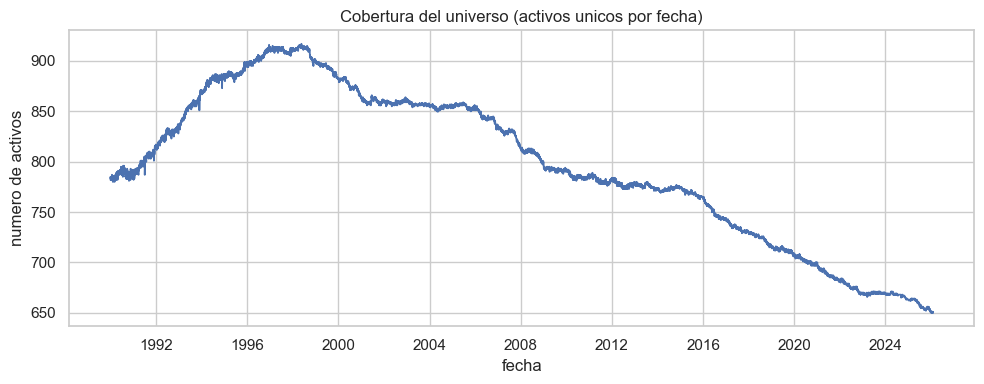

In [16]:
# Visual: cobertura del universo por fecha
if columna_fecha is not None and columna_activo is not None:
    cobertura_df = (
        datos_auditoria_df.dropna(subset=[columna_fecha])
        .groupby(columna_fecha)[columna_activo]
        .nunique()
        .reset_index(name="n_activos")
    )
    plt.figure(figsize=(10, 4))
    plt.plot(cobertura_df[columna_fecha], cobertura_df["n_activos"], linewidth=1.3)
    plt.title("Cobertura del universo (activos unicos por fecha)")
    plt.xlabel("fecha")
    plt.ylabel("numero de activos")
    plt.tight_layout()
    plt.show()


## 4) Distribucion y Riesgo


In [17]:
# Trabajamos directamente con el dataset original (sin recalcular features)
datos_analisis_df = datos_base_df.copy()

# Normalizamos nombres de metricas existentes para que el resto del notebook sea consistente
metricas_alias = {
    "retorno_1d": ["retorno_1d", "ret_1d", "return_1d", "daily_return"],
    "log_retorno_1d": ["log_retorno_1d", "log_ret_1d", "log_return_1d"],
    "volatilidad_21d_anual": ["volatilidad_21d_anual", "vol_21d_anual", "volatility_21d_annual", "volatility_21d"],
    "drawdown": ["drawdown", "dd"],
    "dollar_volume": ["dollar_volume", "dollar_vol", "turnover_dollar"]
}

columnas_normalizadas = []
for objetivo, aliases in metricas_alias.items():
    if objetivo in datos_analisis_df.columns:
        columnas_normalizadas.append(objetivo)
        continue

    origen = next((c for c in aliases if c in datos_analisis_df.columns), None)
    if origen is not None:
        datos_analisis_df[objetivo] = datos_analisis_df[origen]
        columnas_normalizadas.append(objetivo)

if columna_fecha is not None and columna_activo is not None:
    datos_analisis_df = datos_analisis_df.sort_values([columna_activo, columna_fecha]).reset_index(drop=True)
elif columna_fecha is not None:
    datos_analisis_df = datos_analisis_df.sort_values(columna_fecha).reset_index(drop=True)


## 6) Ranking de activos para gestion


In [18]:
if columna_activo is None:
    print("No hay columna de activo; no se puede crear ranking cross-sectional.")
    ranking_activos_df = pd.DataFrame()
else:
    datos_ranking_df = datos_analisis_df.copy()

    # Fallback: si faltan metricas clave, se calculan con la columna de precio referencia.
    if columna_precio_referencia is None or columna_precio_referencia not in datos_ranking_df.columns:
        print("No hay columna de precio referencia; no se puede calcular ranking.")
        ranking_activos_df = pd.DataFrame()
    else:
        if "retorno_1d" not in datos_ranking_df.columns:
            if columna_activo is not None:
                datos_ranking_df["retorno_1d"] = (
                    datos_ranking_df.groupby(columna_activo)[columna_precio_referencia].pct_change()
                )
            else:
                datos_ranking_df["retorno_1d"] = datos_ranking_df[columna_precio_referencia].pct_change()

        if "volatilidad_21d_anual" not in datos_ranking_df.columns:
            if "retorno_1d" in datos_ranking_df.columns:
                if columna_activo is not None:
                    datos_ranking_df["volatilidad_21d_anual"] = (
                        datos_ranking_df.groupby(columna_activo)["retorno_1d"]
                        .transform(lambda s: s.rolling(21, min_periods=10).std() * np.sqrt(252))
                    )
                else:
                    datos_ranking_df["volatilidad_21d_anual"] = (
                        datos_ranking_df["retorno_1d"].rolling(21, min_periods=10).std() * np.sqrt(252)
                    )

        if "drawdown" not in datos_ranking_df.columns:
            if columna_activo is not None:
                max_roll = (
                    datos_ranking_df.groupby(columna_activo)[columna_precio_referencia]
                    .transform(lambda s: s.rolling(252, min_periods=20).max())
                )
            else:
                max_roll = datos_ranking_df[columna_precio_referencia].rolling(252, min_periods=20).max()

            datos_ranking_df["drawdown"] = (
                datos_ranking_df[columna_precio_referencia] / max_roll - 1
            )

        # Liquidez opcional
        if "dollar_volume" not in datos_ranking_df.columns and columna_volumen is not None and columna_volumen in datos_ranking_df.columns:
            datos_ranking_df["dollar_volume"] = (
                datos_ranking_df[columna_precio_referencia] * datos_ranking_df[columna_volumen]
            )

        columnas_necesarias = ["retorno_1d", "volatilidad_21d_anual", "drawdown"]
        faltantes = [c for c in columnas_necesarias if c not in datos_ranking_df.columns]

        if len(faltantes) > 0:
            print("No se puede crear ranking. Faltan columnas:", faltantes)
            ranking_activos_df = pd.DataFrame()
        else:
            agregaciones = {
                "observaciones": (columna_precio_referencia, "count"),
                "retorno_medio_diario": ("retorno_1d", "mean"),
                "volatilidad_media_anual": ("volatilidad_21d_anual", "mean"),
                "drawdown_peor": ("drawdown", "min")
            }

            if "dollar_volume" in datos_ranking_df.columns:
                agregaciones["liquidez_mediana"] = ("dollar_volume", "median")

            ranking_activos_df = datos_ranking_df.groupby(columna_activo).agg(**agregaciones)

            ranking_activos_df["retorno_anual_aprox"] = ranking_activos_df["retorno_medio_diario"] * 252
            ranking_activos_df["sharpe_aprox"] = (
                ranking_activos_df["retorno_anual_aprox"] /
                ranking_activos_df["volatilidad_media_anual"].replace(0, np.nan)
            )

            # Filtro minimo para evitar ranking con series muy cortas
            ranking_activos_df = ranking_activos_df[ranking_activos_df["observaciones"] >= 126]

            # Priorizamos Sharpe alto, drawdown menos profundo y liquidez
            columnas_orden = ["sharpe_aprox", "drawdown_peor"]
            ascendentes = [False, False]

            if "liquidez_mediana" in ranking_activos_df.columns:
                columnas_orden.append("liquidez_mediana")
                ascendentes.append(False)

            ranking_activos_df = ranking_activos_df.sort_values(columnas_orden, ascending=ascendentes)

            print("Top 20 activos segun perfil riesgo-retorno:")
            display(ranking_activos_df.head(20))


Top 20 activos segun perfil riesgo-retorno:


,observaciones,retorno_medio_diario,volatilidad_media_anual,drawdown_peor,liquidez_mediana,retorno_anual_aprox,sharpe_aprox
symbol,,,,,,,
YELLQ,8993,0.064602,3.130932,-0.999982,5.000032e+06,16.279663,5.199622
BIGGQ,9084,0.036331,2.416067,-0.999943,1.722162e+07,9.155400,3.789381
SNDK,242,0.013503,0.911268,-0.475009,2.274805e+08,3.402667,3.733992
SIVBQ-202411,8746,0.018139,1.501537,-0.999996,1.520378e+07,4.570991,3.044208
GWOW-201009,3319,0.046271,3.876087,-0.999855,1.852500e+04,11.660362,3.008281
FRCB,3806,0.015819,1.496945,-0.999932,5.087420e+07,3.986301,2.662957
GHC-199308,135,0.004856,0.503594,-0.218182,6.628088e+06,1.223786,2.430103
NRT-199008,153,0.003148,0.347457,-0.227658,1.242000e+07,0.793407,2.283467
MZIAQ-201302,5365,0.012768,1.464534,-0.997895,7.489625e+05,3.217596,2.197010


In [ ]:
# Top activos por retorno anual aproximado
if "resumen_rr_df" not in globals() or not isinstance(resumen_rr_df, pd.DataFrame) or resumen_rr_df.empty:
    if columna_activo is None or columna_precio_referencia is None:
        print("No se puede construir resumen_rr_df: faltan columna_activo o columna_precio_referencia.")
        resumen_rr_df = pd.DataFrame()
    else:
        datos_tmp = datos_analisis_df.copy()

        if "retorno_1d" not in datos_tmp.columns:
            datos_tmp["retorno_1d"] = datos_tmp.groupby(columna_activo)[columna_precio_referencia].pct_change()

        if "volatilidad_21d_anual" not in datos_tmp.columns:
            datos_tmp["volatilidad_21d_anual"] = (
                datos_tmp.groupby(columna_activo)["retorno_1d"]
                .transform(lambda s: s.rolling(21, min_periods=10).std() * np.sqrt(252))
            )

        if "drawdown" not in datos_tmp.columns:
            max_roll = (
                datos_tmp.groupby(columna_activo)[columna_precio_referencia]
                .transform(lambda s: s.rolling(252, min_periods=20).max())
            )
            datos_tmp["drawdown"] = datos_tmp[columna_precio_referencia] / max_roll - 1

        resumen_rr_df = (
            datos_tmp.groupby(columna_activo)
            .agg(
                observaciones=(columna_precio_referencia, "count"),
                retorno_medio_diario=("retorno_1d", "mean"),
                volatilidad_media_anual=("volatilidad_21d_anual", "mean"),
                drawdown_peor=("drawdown", "min")
            )
            .reset_index()
        )

        resumen_rr_df = resumen_rr_df[resumen_rr_df["observaciones"] >= 126].copy()
        resumen_rr_df["retorno_anual_aprox"] = resumen_rr_df["retorno_medio_diario"] * 252

if isinstance(resumen_rr_df, pd.DataFrame) and len(resumen_rr_df) > 0:
    top_retorno = (
        resumen_rr_df
        .sort_values("retorno_anual_aprox", ascending=False)
        [[columna_activo, "retorno_anual_aprox", "volatilidad_media_anual", "drawdown_peor", "observaciones"]]
        .head(15)
    )
    display(top_retorno)
else:
    print("No hay resumen_rr_df disponible para mostrar top retornos.")

# Dias con retornos diarios extremos (positivos y negativos)
if "retorno_1d" not in datos_analisis_df.columns and columna_activo is not None and columna_precio_referencia is not None:
    datos_analisis_df["retorno_1d"] = datos_analisis_df.groupby(columna_activo)[columna_precio_referencia].pct_change()

if "retorno_1d" in datos_analisis_df.columns:
    cols_evento = [c for c in [columna_fecha, columna_activo, "retorno_1d", columna_precio_referencia] if c is not None]
    display(datos_analisis_df.nlargest(15, "retorno_1d")[cols_evento])
    display(datos_analisis_df.nsmallest(15, "retorno_1d")[cols_evento])
else:
    print("No existe retorno_1d para mostrar eventos extremos.")


,symbol,retorno_anual_aprox,volatilidad_media_anual,drawdown_peor,observaciones
1280,YELLQ,16.279663,3.130932,-0.999982,8993
546,GWOW-201009,11.660362,3.876087,-0.999855,3319
149,BIGGQ,9.155400,2.416067,-0.999943,9084
1035,SIVBQ-202411,4.570991,1.501537,-0.999996,8746
475,FRCB,3.986301,1.496945,-0.999932,3806
1049,SNDK,3.402667,0.911268,-0.475009,242
805,MZIAQ-201302,3.217596,1.464534,-0.997895,5365
593,HTMXQ-201305,3.065241,1.491343,-0.998022,5567
624,ISS-199206,1.853072,2.248858,-0.928571,629
1155,TUPBQ-202506,1.396176,0.774825,-0.999961,7311


,date,symbol,retorno_1d,close
7210930,2025-12-24,YELLQ,299.000000,0.0300
7210943,2026-01-27,YELLQ,199.000000,0.0200
877779,2025-06-03,BIGGQ,111.500008,0.0225
5813882,2024-03-12,SIVBQ-202411,83.615387,0.1100
3015185,2007-01-23,GWOW-201009,61.500004,0.0500
5813878,2024-03-06,SIVBQ-202411,52.846153,0.0700
7210905,2025-10-30,YELLQ,49.000000,0.0500
877790,2025-06-18,BIGGQ,48.999996,0.0150
877819,2025-08-01,BIGGQ,48.999996,0.0300
877822,2025-08-06,BIGGQ,39.000000,0.0600


,date,symbol,retorno_1d,close
5673113,2023-03-28,SBNY,-0.998143,0.130000
7210929,2025-12-23,YELLQ,-0.996667,0.000100
5813642,2023-03-28,SIVBQ-202411,-0.996228,0.400000
877799,2025-07-02,BIGGQ,-0.996000,0.000100
877812,2025-07-23,BIGGQ,-0.995000,0.000200
7210942,2026-01-26,YELLQ,-0.995000,0.000100
877788,2025-06-16,BIGGQ,-0.987500,0.000200
877795,2025-06-26,BIGGQ,-0.987500,0.000200
5813877,2024-03-05,SIVBQ-202411,-0.983750,0.001300
5813881,2024-03-11,SIVBQ-202411,-0.978333,0.001300
